# Libraries and functions

In [14]:
import numpy as np
import matplotlib.pyplot as plt


def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


def rhm_level_floors(v: int, m: int, s: int, L: int):
    """
    Equal-probability RHM level floors.

    f = m / v^(s-1)
    Nbar_l ≈ 1/(1-f) + v f^l
    L_l ≈ log Nbar_l
    E_l ≈ 1 - 1/Nbar_l
    A_l ≈ 1/Nbar_l
    """
    f = m / (v ** (s - 1))
    if not (0 < f < 1):
        raise ValueError(
            f"Need 0 < f = m / v^(s-1) < 1, got f={f:.6g}. "
            "Choose m < v^(s-1)."
        )

    levels = np.arange(L + 1)
    Nbar = 1.0 / (1.0 - f) + v * (f ** levels)
    loss_floors = np.log(Nbar)
    err_floors = 1.0 - 1.0 / Nbar
    acc_floors = 1.0 / Nbar
    return levels, Nbar, loss_floors, err_floors, acc_floors, f


def rhm_solved_fractions(norm, m: int, s: int, L: int, beta: float = 12.0):
    """
    Cumulative solved fractions r_l(norm), with norm normalized so that
    norm = 1 is the first shoulder.

    r_0 = 1
    r_l = sigmoid[ beta * (norm * m^(1-l) * r_(l-1)^s - 1) ]
    """
    norm = np.asarray(norm, dtype=float)
    r = np.zeros((L + 1, norm.size), dtype=float)
    r[0] = 1.0

    for ell in range(1, L + 1):
        margin = norm * (m ** (1 - ell)) * (r[ell - 1] ** s) - 1.0
        r[ell] = sigmoid(beta * margin)

    return r


def rhm_ideal_curves(norm, v: int, m: int, s: int, L: int, beta: float = 12.0):
    levels, Nbar, Lfloors, Efloors, Afloors, f = rhm_level_floors(v, m, s, L)
    r = rhm_solved_fractions(norm, m=m, s=s, L=L, beta=beta)

    dL = Lfloors[:-1] - Lfloors[1:]
    dE = Efloors[:-1] - Efloors[1:]
    dA = Afloors[1:] - Afloors[:-1]

    loss = Lfloors[0] - np.tensordot(dL, r[1:], axes=(0, 0))
    err = Efloors[0] - np.tensordot(dE, r[1:], axes=(0, 0))
    acc = Afloors[0] + np.tensordot(dA, r[1:], axes=(0, 0))

    return {
        "norm": np.asarray(norm, dtype=float),
        "r": r,
        "levels": levels,
        "Nbar": Nbar,
        "loss_floors": Lfloors,
        "err_floors": Efloors,
        "acc_floors": Afloors,
        "loss": loss,
        "err": err,
        "acc": acc,
        "f": f,
    }


def plot_rhm_ideal_curves(
    v: int,
    m: int,
    s: int,
    L: int,
    beta: float = 12.0,
    norm_min: float = 1e-2,
    norm_max: float = 1e4,
    num_points: int = 1200,
    show_level_lines: bool = True,
    figsize=(12, 4.6),
):
    norm = np.logspace(np.log10(norm_min), np.log10(norm_max), num_points)
    out = rhm_ideal_curves(norm, v=v, m=m, s=s, L=L, beta=beta)

    fig, axes = plt.subplots(1, 2, figsize=figsize, constrained_layout=True)

    ax = axes[0]
    ax.plot(out["norm"], 1-out["acc"], lw=2)
    if show_level_lines:
        for a in out["acc_floors"]:
            ax.axhline(1-a, ls="--", lw=0.8, alpha=0.5)
    #ax.axvline(1.0, ls=":", lw=1.2, alpha=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"normalized norm $\mathcal{N}/\mathcal{N}_1^c$")
    ax.set_ylabel("error")
    ax.set_title("Ideal RHM error vs norm")

    ax = axes[1]
    ax.plot(out["norm"], out["loss"], lw=2)
    if show_level_lines:
        for lf in out["loss_floors"]:
            ax.axhline(lf, ls="--", lw=0.8, alpha=0.5)
    #ax.axvline(1.0, ls=":", lw=1.2, alpha=0.8)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlabel(r"normalized norm $\mathcal{N}/\mathcal{N}_1^c$")
    ax.set_ylabel("cross-entropy loss")
    ax.set_title("Ideal RHM loss vs norm")

    fig.suptitle(
        f"Equal-probability RHM toy theory (v={v}, m={m}, s={s}, L={L}, beta={beta})",
        y=1.03
    )
    return fig, axes, out


# Test

## L=3, s=2, v=32, m=8

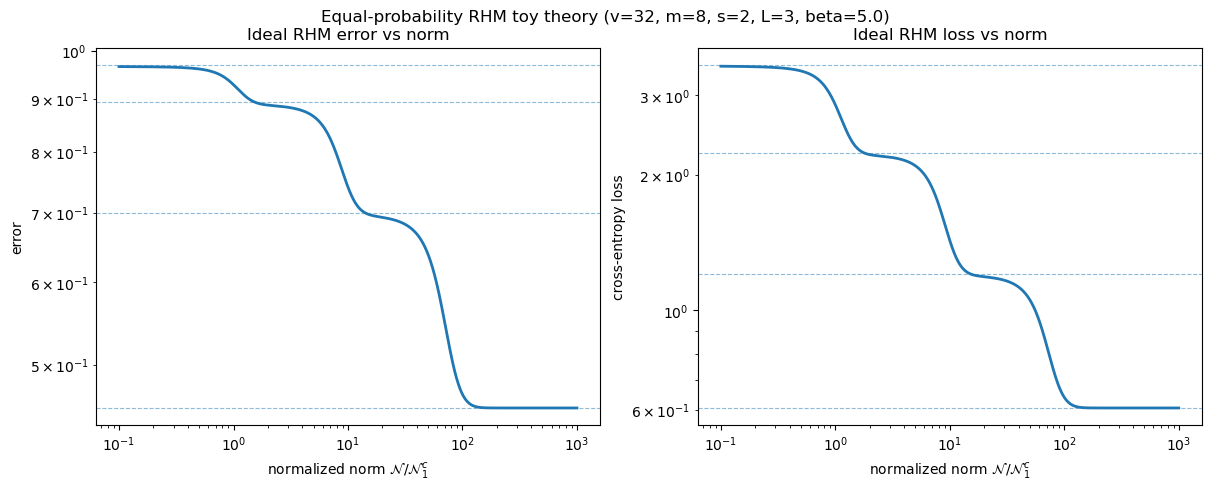

In [16]:
fig, axes, out = plot_rhm_ideal_curves(v=32, m=8, s=2, L=3, beta=5.0, norm_min=0.1, norm_max=1e3)
plt.show()

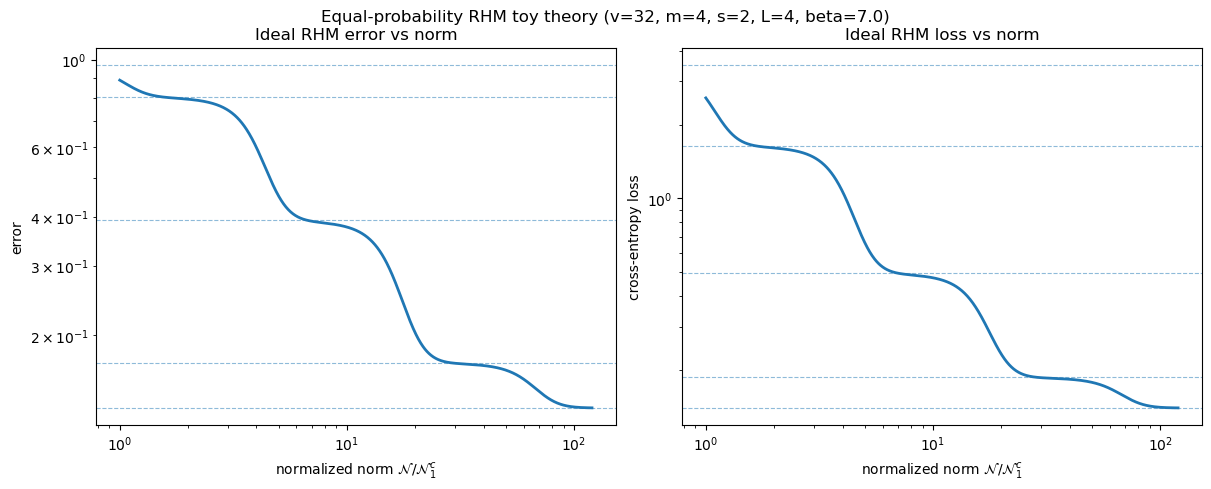

In [19]:
fig, axes, out = plot_rhm_ideal_curves(v=32, m=4, s=2, L=4, beta=7.0, norm_min=1., norm_max=1.2e2)
plt.show()